In [14]:
import pandas as pd
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

In [6]:
content = pd.read_csv("participant_content.csv")
content

,sessionId,treatmentArm,participantCode,profilePicture,firstName,lastName,bio,postOrCommentId,userContent,staticContent,dynamicContent,postOrCommentText,postOrCommentDate,postLikes,postDislikes,participantLiked,participantDisliked,parentPost,previousCommentOrPost,dwellTimeInSeconds
0,657896b96d158d001f181516,imm_treat,8gch37,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,enigma.897,NaN,Putting empathy into motion for a brighter tom...,654e2ecbf18dbd001f7aadfc,0,1,0,I'm honestly curious about what the other side...,2023-12-12T17:18:10.943Z,76.0,12.0,0.0,0.0,NaN,NaN,50
1,657896b96d158d001f181516,imm_treat,8gch37,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,free.thinker,NaN,"Faithful, family-oriented, and not afraid to r...",654e66afae0ef3001e0a2146,0,1,0,"I mean I think is worse now, in part because o...",NaN,NaN,NaN,NaN,NaN,654e2ecbf18dbd001f7aadfc,654e2ecbf18dbd001f7aadfc,0
2,657896b96d158d001f181516,imm_treat,8gch37,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Taylor_C,NaN,NaN,654e66afae0ef3001e0a2148,0,1,0,Hope this starts a real conversation! 😸,NaN,NaN,NaN,NaN,NaN,654e2ecbf18dbd001f7aadfc,654e66afae0ef3001e0a2146,0
3,657896b96d158d001f181516,imm_treat,8gch37,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Sam_theFan,NaN,"Ditching plastic, hugging trees, and fighting ...",656b975e83a42f001fcb95c8,0,1,0,👏👏👏,NaN,NaN,NaN,NaN,NaN,654e2ecbf18dbd001f7aadfc,654e66afae0ef3001e0a2148,0
4,657896b96d158d001f181516,imm_treat,8gch37,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Taylor.C,NaN,NaN,656b975e83a42f001fcb95ca,0,1,0,Enigma for congress 2024 😉 you'd have my vote!,NaN,NaN,NaN,NaN,NaN,654e2ecbf18dbd001f7aadfc,656b975e83a42f001fcb95c8,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104407,657b64a78b12dc001f06215b,imm_control3,h63zav,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Shan,NaN,"Jersey girl, born and raised!!! I love animals...",657b66cb8b12dc001f07eca7,1,0,0,"The over crowding, congestion and increased de...",2023-12-14T20:34:19.040Z,0.0,3.0,0.0,0.0,NaN,NaN,0
104408,657b64a78b12dc001f06215b,imm_control3,h63zav,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Shan,NaN,"Jersey girl, born and raised!!! I love animals...",657b670e8b12dc001f085097,1,0,0,"Wellll, if we keep allowing every person into ...",2023-12-14T20:35:26.579Z,NaN,NaN,NaN,NaN,657b66cb8b12dc001f07eca7,657b66cb8b12dc001f07eca7,0
104409,657b64a78b12dc001f06215b,imm_control3,h63zav,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,enigma.897,NaN,Putting empathy into motion for a brighter tom...,657b67248b12dc001f0872c2,0,0,1,"I can see where you're coming from, but it's i...",2023-12-14T20:35:48.079Z,NaN,NaN,NaN,NaN,657b66cb8b12dc001f07eca7,657b670e8b12dc001f085097,0
104410,657b64a78b12dc001f06215b,imm_control3,h63zav,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,verbal_latte,NaN,Melding technology with activism for positive ...,657b66ce8b12dc001f07f104,0,0,1,Undocumented immigrants contribute to the econ...,2023-12-14T20:34:22.249Z,1.0,0.0,1.0,0.0,NaN,NaN,0


In [11]:
data = {}

for ind, row in content.iterrows():
    i = row['participantCode']
    if i not in data:
        data[i] = {"likes": 0,
                   "dislikes": 0,
                   "op": 0,
                   "comments": 0}
    if row['participantLiked'] == 1:
        data[i]['likes'] += 1
    if row['participantDisliked'] == 1:
        data[i]['dislikes'] += 1
    if row['userContent'] == 1:
        if pd.isnull(row['parentPost']):
            data[i]['comments'] += 1
        else:
            data[i]['op'] += 1

df = pd.DataFrame.from_dict(data, orient="index").reset_index(names="participant_code")
df

,participant_code,likes,dislikes,op,comments
0,8gch37,2,5,2,1
1,nyuhem,2,0,1,1
2,gw6r7f,1,0,1,1
3,hfyv7m,1,0,1,1
4,17xpyv,1,2,1,1
...,...,...,...,...,...
1038,11frdz,5,0,3,1
1039,uewkay,1,0,1,1
1040,qby6gb,0,0,1,1
1041,pqdpcp,5,3,1,1


In [13]:
df = df.merge(pd.read_csv("Cleaned_study_data.csv"), validate="1:1")
df

,participant_code,likes,dislikes,op,comments,StartDate_post,EndDate_post,Status_post,IPAddress_post,Progress_post,...,ih_dwell_p,mc_correct,n_op,n_comments,zip_state_match,speeder,commented,posted,passcode,gold_star
0,8gch37,2,5,2,1,12/12/2023 10:34,12/12/2023 10:37,IP Address,71.71.112.54,100,...,0.220734,1,1,2,1,0,1,1,True,0
1,nyuhem,2,0,1,1,12/12/2023 10:46,12/12/2023 10:52,IP Address,172.58.10.215,100,...,0.109973,1,1,1,1,1,1,1,True,1
2,gw6r7f,1,0,1,1,12/12/2023 10:47,12/12/2023 10:56,IP Address,66.212.218.70,100,...,0.141557,1,1,1,1,1,1,1,True,1
3,hfyv7m,1,0,1,1,12/12/2023 10:52,12/12/2023 11:06,IP Address,174.215.176.210,100,...,0.181847,1,1,1,1,1,1,1,True,1
4,17xpyv,1,2,1,1,12/12/2023 10:55,12/12/2023 11:00,IP Address,68.116.85.163,100,...,0.036418,1,1,1,1,1,1,1,True,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1038,11frdz,5,0,3,1,12/14/2023 12:12,12/14/2023 12:19,IP Address,47.50.90.2,100,...,NaN,0,1,3,1,1,1,1,True,0
1039,uewkay,1,0,1,1,12/14/2023 12:34,12/14/2023 12:38,IP Address,172.0.49.80,100,...,0.200000,1,1,1,1,1,1,1,True,1
1040,qby6gb,0,0,1,1,12/14/2023 12:47,12/14/2023 12:50,IP Address,68.46.77.117,100,...,NaN,1,1,1,1,1,1,1,True,1
1041,pqdpcp,5,3,1,1,12/14/2023 13:24,12/14/2023 13:31,IP Address,96.245.37.52,100,...,NaN,1,1,1,1,1,1,1,True,1


In [10]:
df['engage1'] = df.

0       8gch37
1       nyuhem
2       gw6r7f
3       17xpyv
4       hfyv7m
         ...  
1038    r9hyrv
1039    3naupc
1040    6fxpk1
1041    pwghnt
1042    nbwdbg
Name: participant_code, Length: 1043, dtype: object

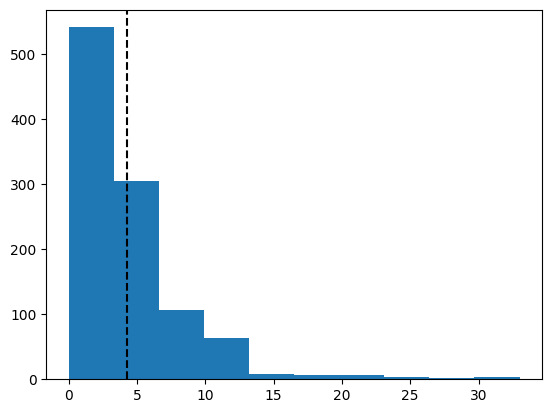

In [17]:
plt.hist(df.likes)
plt.axvline(df.likes.mean(), color="black", ls="--")
plt.show()

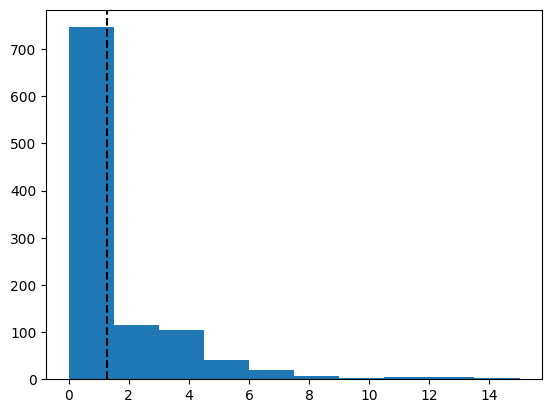

In [18]:
plt.hist(df.dislikes)
plt.axvline(df.dislikes.mean(), color="black", ls="--")
plt.show()

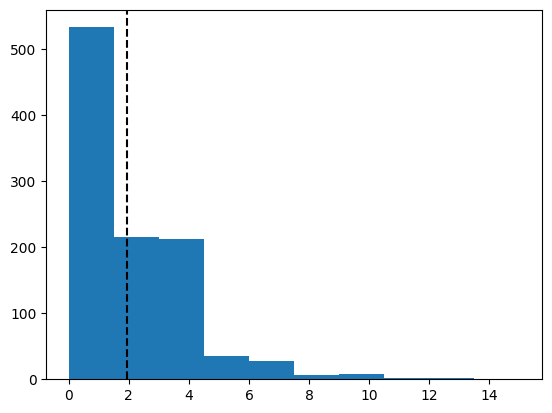

In [19]:
plt.hist(df.op)
plt.axvline(df.op.mean(), color="black", ls="--")
plt.show()

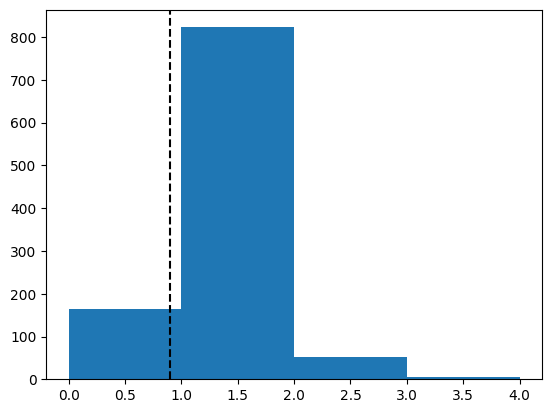

In [21]:
plt.hist(df.comments, bins=[0,1,2,3,4])
plt.axvline(df.comments.mean(), color="black", ls="--")
plt.show()

In [22]:
df['engage1'] = df.likes + df.dislikes
df['engage2'] = df.op + df.comments
df['engage3'] = df.likes + df.dislikes + df.op + df.comments

C:\Users\Austin\AppData\Local\Temp\ipykernel_18796\772675809.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['engage1'] = df.likes + df.dislikes
C:\Users\Austin\AppData\Local\Temp\ipykernel_18796\772675809.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['engage2'] = df.op + df.comments
C:\Users\Austin\AppData\Local\Temp\ipykernel_18796\772675809.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining al

In [24]:
for y in ['likes', 'dislikes', 'op', 'comments', 'engage1', 'engage2', 'engage3']:
    print(y, stats.ttest_ind(df[df.condition == "treat"][y],
                             df[df.condition == "control"][y]))

likes Ttest_indResult(statistic=1.559604625918852, pvalue=0.11915728265389608)
dislikes Ttest_indResult(statistic=1.2404521420129935, pvalue=0.21508770621541254)
op Ttest_indResult(statistic=-1.0560797419428996, pvalue=0.2911768072053215)
comments Ttest_indResult(statistic=0.8438410850820971, pvalue=0.39895207695115653)
engage1 Ttest_indResult(statistic=1.6431903571163018, pvalue=0.10064553144106214)
engage2 Ttest_indResult(statistic=-0.7819772925663804, pvalue=0.4344057390111239)
engage3 Ttest_indResult(statistic=1.2890286153049453, pvalue=0.19767449893586658)


In [23]:
for y in ['likes', 'dislikes', 'op', 'comments', 'engage1', 'engage2', 'engage3']:
    print(y, stats.ranksums(df[df.condition == "treat"][y],
                           df[df.condition == "control"][y]))

likes RanksumsResult(statistic=1.339821203658395, pvalue=0.1803034803909379)
dislikes RanksumsResult(statistic=0.4000940737191889, pvalue=0.6890872289995648)
op RanksumsResult(statistic=-0.615268124168475, pvalue=0.5383776648134553)
comments RanksumsResult(statistic=0.6294689940690017, pvalue=0.5290420614352518)
engage1 RanksumsResult(statistic=1.3912736308342166, pvalue=0.16414246682308198)
engage2 RanksumsResult(statistic=-0.3560507960566856, pvalue=0.7218025247207991)
engage3 RanksumsResult(statistic=0.9707014910990507, pvalue=0.33169694913214054)
